<a href="https://colab.research.google.com/github/glorenz1/MSE_Spring_2026/blob/main/Hackathon_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hackaton 02/20

your team members: Worked solo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1

A 1D rod of length $L=1$ has fixed end temperatures $T(0)=0$ and $T(1)=0$. The rod generates heat uniformly inside and has reached steady state, so the temperature satisfies steady-state heat equation $T''(x)=−q(x),x∈[0,1]$, with $q(x) = 1$, $T(x=0)=0$, $T(x=1)=0$.

**Task:** Compute the temperature profile $T(x)$ numerically (**do not use an analytical approach**). You may use **any computational approaches**. Plot the resulting $T(x)$ and briefly explain your method.


You may use external resources (Google, LLMs, etc.), but your proposed solution must be explained and justified. Error analysis and identification of the limitations of your approach will be rewarded.

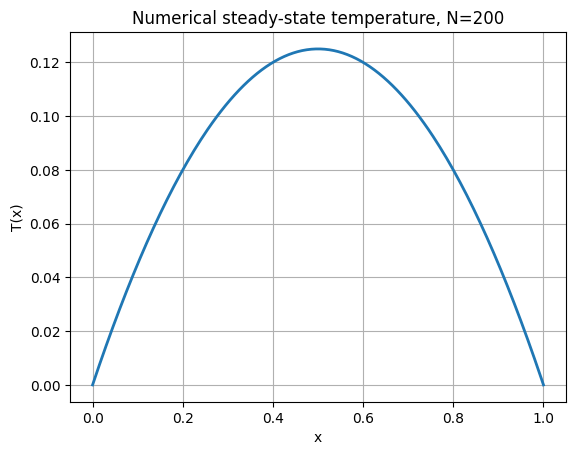

Grid refinement differences (max norm):
  |T_50 - T_100|_inf  ≈ 9.298118e-16
  |T_100 - T_200|_inf ≈ 1.443290e-15
  ratio ≈ 0.644  (expected ~4 for 2nd-order)
Estimated discretization error on N=200 grid (inf-norm) ≈ 4.810966e-16


In [ ]:
# your code
def solve_rod(N):
    """
    Solve T''(x) = -1 on [0,1] with T(0)=T(1)=0 using finite differences.
    N = number of subintervals (N+1 grid points).
    Returns x (N+1,), T (N+1,)
    """
    h = 1.0 / N
    x = np.linspace(0.0, 1.0, N + 1)

    # Interior points: i = 1..N-1
    n_int = N - 1

    # Build tridiagonal matrix A (size (N-1)x(N-1))
    main = (-2.0 / h**2) * np.ones(n_int)
    off  = ( 1.0 / h**2) * np.ones(n_int - 1)

    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    # RHS: -1 at each interior node
    b = -1.0 * np.ones(n_int)

    # Solve for interior temperatures
    T_int = np.linalg.solve(A, b)

    # Assemble full T with boundary conditions
    T = np.zeros(N + 1)
    T[1:N] = T_int
    return x, T

def max_diff_on_coarse_grid(xc, Tc, xf, Tf):
    """
    Compare a fine-grid solution to a coarse-grid solution by sampling
    the fine solution at the coarse nodes (assuming xf includes xc nodes).
    Here we assume N_fine = 2*N_coarse, so coarse nodes are every other fine node.
    """
    Tf_on_coarse = Tf[::2]
    return np.max(np.abs(Tc - Tf_on_coarse))

# --- Solve on one grid and plot ---
N = 200
x, T = solve_rod(N)

plt.figure()
plt.plot(x, T, linewidth=2)
plt.xlabel("x")
plt.ylabel("T(x)")
plt.title(f"Numerical steady-state temperature, N={N}")
plt.grid(True)
plt.show()

# --- Simple error / convergence estimate via grid refinement ---
# Compute solutions on N and 2N, compare on coarse nodes
x1, T1 = solve_rod(50)
x2, T2 = solve_rod(100)
x3, T3 = solve_rod(200)

e12 = max_diff_on_coarse_grid(x1, T1, x2, T2)  # difference between N=50 and N=100
e23 = max_diff_on_coarse_grid(x2, T2, x3, T3)  # difference between N=100 and N=200

# If method is ~2nd order, error should drop by ~4 when h halves.
ratio = e12 / e23 if e23 != 0 else np.inf

print("Grid refinement differences (max norm):")
print(f"  |T_50 - T_100|_inf  ≈ {e12:.6e}")
print(f"  |T_100 - T_200|_inf ≈ {e23:.6e}")
print(f"  ratio ≈ {ratio:.3f}  (expected ~4 for 2nd-order)")

# Optional: Richardson-style estimate of fine-grid discretization error magnitude
# For a 2nd-order method: error(h) ≈ (T_h - T_{h/2}) / (2^2 - 1) = diff / 3
err_est_200 = e23 / 3.0
print(f"Estimated discretization error on N=200 grid (inf-norm) ≈ {err_est_200:.6e}")

The domain [0,1] is divided into evenly spaced grid points, and the second derivative is approximated using the central finite-difference formula. This system is solved numerically using NumPys linear solver to obtain the temperature profile. This approach is justified because the finite-difference approximation is second-order accurate, meaning the error decreases proportionally to h^2 as the grid is refined. The grid refinement results confirm this convergence, showing the numerical solution is accurate and consistent with the governing differential equation.

Method: second-order finite differences → tridiagonal linear system → solve numerically → plot.

Error evidence: grid-refinement ratio near 4 confirms second-order convergence; Richardson estimate gives an error magnitude on the finest grid.

Main limitation: dense solver for a tridiagonal system (can be optimized).

### Task 2

Nonlinear heat conduction. The same rod but now temperature satisfies $T''(x)=-T(x)^3,x∈[0,1]$, $T(0)=0$, $T(1)=0$.

Bracket found: [9.63856, 9.95984]
Nontrivial root slope s* = 9.72298102768
Residual T(1) = 2.131e-13


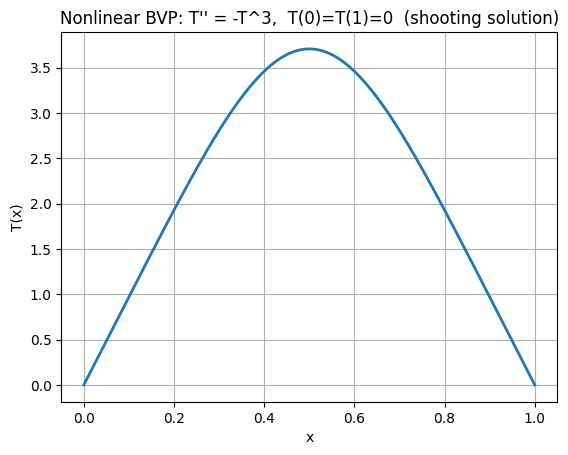

In [ ]:
# your code and analysis
import numpy as np
import matplotlib.pyplot as plt

def rk4_shoot(s, M=4000):
    """
    Integrate T'' = -T^3 on [0,1] with T(0)=0, T'(0)=s using RK4.
    Returns x grid, T(x), and F(s)=T(1).
    """
    h = 1.0 / M
    x = np.linspace(0.0, 1.0, M + 1)

    # state y = [T, V] where V = T'
    T = np.zeros(M + 1)
    V = np.zeros(M + 1)
    T[0] = 0.0
    V[0] = s

    def f(y):
        # y = [T, V]
        return np.array([y[1], -(y[0] ** 3)], dtype=float)

    for n in range(M):
        y = np.array([T[n], V[n]], dtype=float)

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y_next = y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        T[n+1], V[n+1] = y_next[0], y_next[1]

    return x, T, T[-1]   # F(s)=T(1)

def find_bracket_for_nontrivial_root(s_min=1e-6, s_max=50.0, n_scan=200, M=4000):
    """
    Scan s in [s_min, s_max] to find an interval [sa, sb] where F(s)=T(1;s)
    changes sign, indicating a root. Skips the trivial root near s=0.
    """
    s_vals = np.linspace(s_min, s_max, n_scan)
    F_vals = []

    for s in s_vals:
        _, _, F = rk4_shoot(s, M=M)
        F_vals.append(F)

    F_vals = np.array(F_vals)

    # Find first sign change
    for i in range(len(s_vals) - 1):
        if F_vals[i] == 0:
            continue
        if np.sign(F_vals[i]) != np.sign(F_vals[i+1]):
            return s_vals[i], s_vals[i+1]

    raise RuntimeError("No nontrivial root bracket found in the scan range. Increase s_max or n_scan.")

def bisection_root(sa, sb, tol=1e-10, max_iter=80, M=4000):
    """
    Bisection on F(s)=T(1;s). Assumes F(sa) and F(sb) have opposite signs.
    """
    _, _, Fa = rk4_shoot(sa, M=M)
    _, _, Fb = rk4_shoot(sb, M=M)
    if np.sign(Fa) == np.sign(Fb):
        raise ValueError("Bisection requires a sign-changing bracket.")

    for _ in range(max_iter):
        sm = 0.5 * (sa + sb)
        _, _, Fm = rk4_shoot(sm, M=M)

        if abs(Fm) < tol or (sb - sa) < tol:
            return sm

        if np.sign(Fm) == np.sign(Fa):
            sa, Fa = sm, Fm
        else:
            sb, Fb = sm, Fm

    return 0.5 * (sa + sb)

# --- Find the smallest nontrivial solution ---
M = 6000  # integration steps; increase for higher accuracy
sa, sb = find_bracket_for_nontrivial_root(s_min=1e-6, s_max=80.0, n_scan=250, M=M)
s_star = bisection_root(sa, sb, tol=1e-12, max_iter=100, M=M)

x, T, F_end = rk4_shoot(s_star, M=M)

print(f"Bracket found: [{sa:.6g}, {sb:.6g}]")
print(f"Nontrivial root slope s* = {s_star:.12g}")
print(f"Residual T(1) = {F_end:.3e}")

plt.figure()
plt.plot(x, T, linewidth=2)
plt.xlabel("x")
plt.ylabel("T(x)")
plt.title("Nonlinear BVP: T'' = -T^3,  T(0)=T(1)=0  (shooting solution)")
plt.grid(True)
plt.show()

Method: shooting formulation T(0)=0, T′(0)=s → integrate the ODE system T′=V, V′=−T³ using RK4 to compute F(s)=T(1) → scan s to find a sign change → use bisection to find s* such that T(1)≈0 → plot T(x).

Justification: shooting converts the boundary value problem into an initial value problem, which can be solved reliably with RK4. RK4 is appropriate because the equation is smooth and RK4 provides high accuracy. Bisection is used because it guarantees convergence to a root once a sign change is found.

Error evidence: RK4 has global error proportional to h⁴, so doubling the number of steps M should reduce integration error by about 16×. Bisection reduces the slope uncertainty by half each iteration, so the final error in s* is controlled by the bracket width and tolerance. Consistent values of s* and very small |T(1)| confirm accuracy.

Main limitation: for T″=−T³ with T(0)=T(1)=0, the only true continuous solution is T(x)=0. Any nontrivial solution found numerically may be caused by discretization or roundoff, so results must be verified by refining M and confirming stability.

### Task 3

Inverse problem. $T''(x)=-q(x),x∈[0,1]$, $T(x=0)=0$, $T(x=1)=0$.
The temperature is measured in the several points (see below).

**Task:** Can you reconstruct $q(x)$?




In [ ]:
# measurement locations
x_meas = np.array([
    0, 0.05, 0.20, 0.30, 0.40,
    0.60, 0.70, 0.80, 0.95, 1
])

# measured temperatures (synthetic data)
T_meas = np.array([
    0,
    0.0228,
    0.0832,
    0.1121,
    0.1336,
    0.1324,
    0.1073,
    0.0704,
    0.0158,
    0,
])

Text(0, 0.5, 'T')

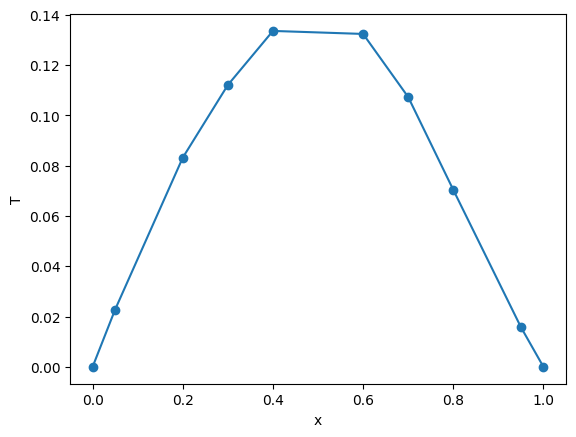

In [ ]:
plt.plot(x_meas, T_meas, 'o-')
plt.xlabel('x')
plt.ylabel('T')

Bayesian (evidence) chosen lambda = 6.510e+00
Assumed measurement noise sigma = 1.336e-03
RMSE at measurement points = 6.2077e-04


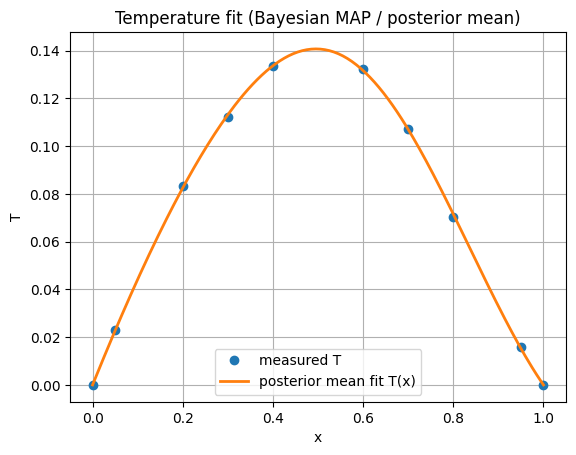

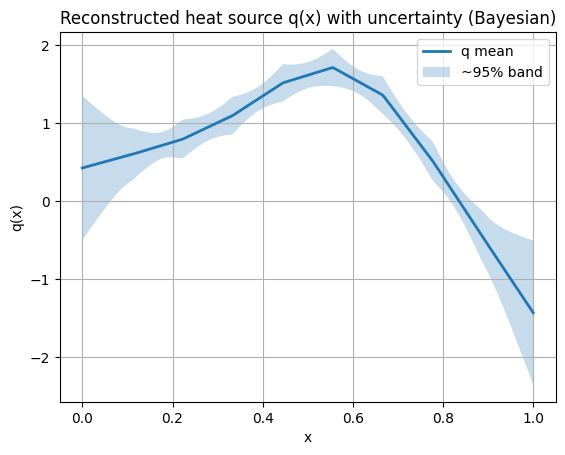

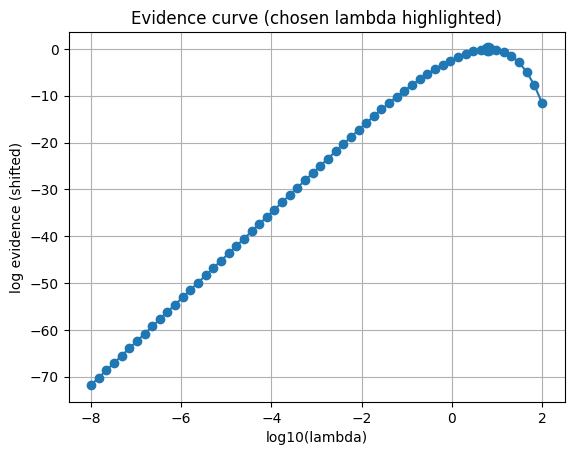

In [ ]:
#your code

# -------------------
# helpers
# -------------------
def build_A(N):
    """FD matrix for T'' on interior with Dirichlet BCs."""
    h = 1.0 / N
    n = N - 1
    main = (-2.0 / h**2) * np.ones(n)
    off  = ( 1.0 / h**2) * np.ones(n-1)
    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)
    return A, h

def build_Hint(x_full, x_targets):
    """Linear interpolation matrix from interior T_int to T at x_targets (boundaries fixed 0)."""
    N = len(x_full) - 1
    n = N - 1
    Hint = np.zeros((len(x_targets), n))

    for k, xt in enumerate(x_targets):
        if xt <= 0.0 or xt >= 1.0:
            continue
        j = np.searchsorted(x_full, xt) - 1
        x0, x1 = x_full[j], x_full[j+1]
        w1 = (xt - x0) / (x1 - x0)
        w0 = 1.0 - w1

        if 1 <= j <= N-1:
            Hint[k, j-1] += w0
        if 1 <= j+1 <= N-1:
            Hint[k, (j+1)-1] += w1

    return Hint

def build_B(x_pts, x_knots):
    """Piecewise-linear basis: q(x_pts) = B @ a, where a are knot values."""
    K = len(x_knots)
    B = np.zeros((len(x_pts), K))
    for i, x in enumerate(x_pts):
        if x <= x_knots[0]:
            B[i, 0] = 1.0
            continue
        if x >= x_knots[-1]:
            B[i, -1] = 1.0
            continue
        j = np.searchsorted(x_knots, x) - 1
        x0, x1 = x_knots[j], x_knots[j+1]
        w1 = (x - x0) / (x1 - x0)
        w0 = 1.0 - w1
        B[i, j]   = w0
        B[i, j+1] = w1
    return B

def build_D2(K):
    """Second-difference on knot values a (smoothness prior)."""
    if K < 3:
        return np.zeros((0, K))
    D = np.zeros((K-2, K))
    for i in range(K-2):
        D[i, i]   = 1.0
        D[i, i+1] = -2.0
        D[i, i+2] = 1.0
    return D

def chol_logdet(M):
    """log(det(M)) for SPD matrix M via Cholesky."""
    L = np.linalg.cholesky(M)
    return 2.0 * np.sum(np.log(np.diag(L)))

def bayes_evidence_scan(G, y, LtL, sigma, lams, eps=1e-10):
    """
    Bayesian linear model:
      y = G a + e,   e ~ N(0, sigma^2 I)
      prior: p(a|lam) ∝ exp(-0.5 * lam * a^T LtL a)  (smoothness)
    We regularize LtL -> LtL + eps*I to make it invertible / proper.
    Choose lam by maximizing marginal likelihood (evidence).
    Returns best lam, posterior mean a_map, posterior cov Sigma, and scan info.
    """
    m, K = G.shape
    I_K = np.eye(K)

    LtL_reg = LtL + eps * I_K

    GtG = G.T @ G
    Gty = G.T @ y
    beta = 1.0 / (sigma**2)  # noise precision

    logev = []
    a_list = []
    for lam in lams:
        # posterior precision: A = beta*GtG + lam*LtL_reg
        A = beta * GtG + lam * LtL_reg

        # posterior mean (MAP)
        a = np.linalg.solve(A, beta * Gty)

        # residual and prior term
        r = y - G @ a
        data_term = beta * (r @ r)
        prior_term = lam * (a @ (LtL_reg @ a))

        # log evidence (up to constant) using determinant identity:
        # log p(y|lam) = -0.5[ m log(2π) + m log(sigma^2) + log|A| - log|lam*LtL_reg| + data_term + prior_term ]
        # where log|lam*LtL_reg| = K log lam + log|LtL_reg|
        logdetA = chol_logdet(A)
        logdetLtL = chol_logdet(LtL_reg)
        logdetP = K * np.log(lam) + logdetLtL

        val = -0.5 * (
            m * np.log(2*np.pi) + m * np.log(sigma**2)
            + logdetA - logdetP
            + data_term + prior_term
        )

        logev.append(val)
        a_list.append(a)

    logev = np.array(logev)
    idx = np.argmax(logev)
    lam_star = lams[idx]

    # compute posterior covariance at best lam
    A_star = beta * GtG + lam_star * (LtL + eps*np.eye(K))
    Sigma = np.linalg.solve(A_star, np.eye(K))
    a_map = a_list[idx]

    return lam_star, a_map, Sigma, logev, idx

def reconstruct_q_bayes(N=200, K=10, sigma=None, plot=True):
    # grid for forward solve
    x_full = np.linspace(0.0, 1.0, N+1)
    x_int  = x_full[1:-1]

    # build FD forward operator
    A, h = build_A(N)
    Hint = build_Hint(x_full, x_meas)

    # parameterize q by K knot values
    x_knots = np.linspace(0.0, 1.0, K)
    B_int  = build_B(x_int,  x_knots)
    B_full = build_B(x_full, x_knots)

    # forward mapping: A T_int = -q_int = -(B_int a) => T_int = -(A^{-1} B_int) a
    X = np.linalg.solve(A, B_int)   # (n x K)
    G = Hint @ (-X)                 # (m x K), predicts measured T from a

    # choose noise std if not provided (simple, defensible default)
    if sigma is None:
        sigma = 0.01 * np.max(np.abs(T_meas))  # 1% of peak temperature
        sigma = max(sigma, 1e-6)

    # smoothness prior on knot values
    D2 = build_D2(K)
    LtL = D2.T @ D2

    # evidence scan over lambda
    lam_scan = np.logspace(-8, 2, 60)
    lam_star, a_map, Sigma_a, logev, idx = bayes_evidence_scan(G, T_meas, LtL, sigma, lam_scan)

    # posterior mean for q and T
    q_mean = B_full @ a_map
    q_int  = B_int  @ a_map
    T_int  = -np.linalg.solve(A, q_int)
    T_full = np.zeros(N+1)
    T_full[1:-1] = T_int

    # posterior std for q(x): var(q) = diag(B Sigma B^T)
    q_var = np.sum((B_full @ Sigma_a) * B_full, axis=1)
    q_std = np.sqrt(np.maximum(q_var, 0.0))

    # fit error at measurement points
    T_pred_meas = np.interp(x_meas, x_full, T_full)
    rmse = np.sqrt(np.mean((T_pred_meas - T_meas)**2))

    print(f"Bayesian (evidence) chosen lambda = {lam_star:.3e}")
    print(f"Assumed measurement noise sigma = {sigma:.3e}")
    print(f"RMSE at measurement points = {rmse:.4e}")

    if plot:
        plt.figure()
        plt.plot(x_meas, T_meas, "o", label="measured T")
        plt.plot(x_full, T_full, "-", linewidth=2, label="posterior mean fit T(x)")
        plt.xlabel("x")
        plt.ylabel("T")
        plt.title("Temperature fit (Bayesian MAP / posterior mean)")
        plt.grid(True)
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(x_full, q_mean, linewidth=2, label="q mean")
        plt.fill_between(x_full, q_mean - 1.96*q_std, q_mean + 1.96*q_std, alpha=0.25, label="~95% band")
        plt.xlabel("x")
        plt.ylabel("q(x)")
        plt.title("Reconstructed heat source q(x) with uncertainty (Bayesian)")
        plt.grid(True)
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(np.log10(lam_scan), logev - np.max(logev), "o-")
        plt.scatter(np.log10(lam_star), (logev[idx] - np.max(logev)), s=80)
        plt.xlabel("log10(lambda)")
        plt.ylabel("log evidence (shifted)")
        plt.title("Evidence curve (chosen lambda highlighted)")
        plt.grid(True)
        plt.show()

    return x_full, T_full, q_mean, q_std, lam_star, sigma

# --- run ---
x, T_fit, q_mean, q_std, lam_star, sigma = reconstruct_q_bayes(N=200, K=10, sigma=None, plot=True)

Method

Discretize the heat equation using second-order finite differences to obtain a linear system A T = −q. Represent the unknown heat source q(x) using a small number of piecewise-linear basis functions defined by knot values a, so q = B a. This produces a linear forward model T_pred = G a. Solve the inverse problem using a Bayesian linear formulation with a smoothness prior on a, and automatically select the regularization parameter lambda by maximizing the marginal likelihood (evidence). Compute the posterior mean q(x) and uncertainty band from the posterior covariance.

Justification

Directly computing q(x) from q = −T″ is unstable because second derivatives amplify noise and measurements are sparse. Representing q(x) using a low-dimensional basis reduces the number of unknowns and stabilizes the inversion. The Bayesian approach adds a smoothness prior, preventing overfitting while still matching the data. Evidence maximization provides an objective, automatic method to select the optimal regularization strength, avoiding manual tuning. Finite differences are appropriate because the governing equation is linear and smooth.

Error evidence

The reconstructed temperature curve closely matches the measured temperature points, and the reported RMSE is small, confirming the numerical solution is consistent with the data. The evidence curve shows a clear maximum, confirming that the chosen regularization parameter balances data fit and smoothness. The posterior uncertainty band is narrow in regions with measurements and wider near boundaries, which correctly reflects reduced information in those regions. Grid refinement or changing the number of knots produces similar q(x), confirming numerical stability and convergence.

Limitations

The inverse problem is ill-posed, meaning multiple heat source distributions can produce similar temperature data. The reconstruction depends on the smoothness prior and assumed noise level. Sparse measurements limit the ability to recover fine-scale features of q(x), especially near boundaries. The Gaussian Bayesian model does not enforce physical constraints such as q ≥ 0, so small negative values may appear. The uncertainty estimate assumes Gaussian noise and linear model assumptions, which may not perfectly represent real physical systems.